RQ4: Screen Time Before Sleep vs Mental Health Analysis

✓ Data loaded successfully: 1000000 records
✓ Required columns found: ['screen_time_before_sleep', 'mental_health_score']

1. DATA PREPARATION: Screen Time Binning
✓ Screen time bins created successfully
  Categories: ['0-15 min', '16-30 min', '31-60 min', '60+ min']

2. SUMMARY STATISTICS BY SCREEN TIME CATEGORY

Mean Mental Health Scores:
screen_bin
0-15 min     7.18
16-30 min    7.17
31-60 min    7.17
60+ min      7.17
Name: mental_health_score, dtype: float64

Detailed Statistics:
             Count  Mean  Std Dev  Min    Q1  Median    Q3   Max
screen_bin                                                      
0-15 min    105569  7.18     1.51  1.0  6.15     7.2  8.26  10.0
16-30 min   203853  7.17     1.50  1.0  6.15     7.2  8.24  10.0
31-60 min   533003  7.17     1.50  1.0  6.15     7.2  8.24  10.0
60+ min     157575  7.17     1.51  1.0  6.14     7.2  8.25  10.0

✓ Summary statistics saved to: C:\Users\patil\output\RQ4_Summa

C:\Users\patil\AppData\Local\Temp\ipykernel_9496\2886094125.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_data = df.groupby("screen_bin")["mental_health_score"]


✓ Saved: RQ4_Figure1_LineChart_ErrorBars.png


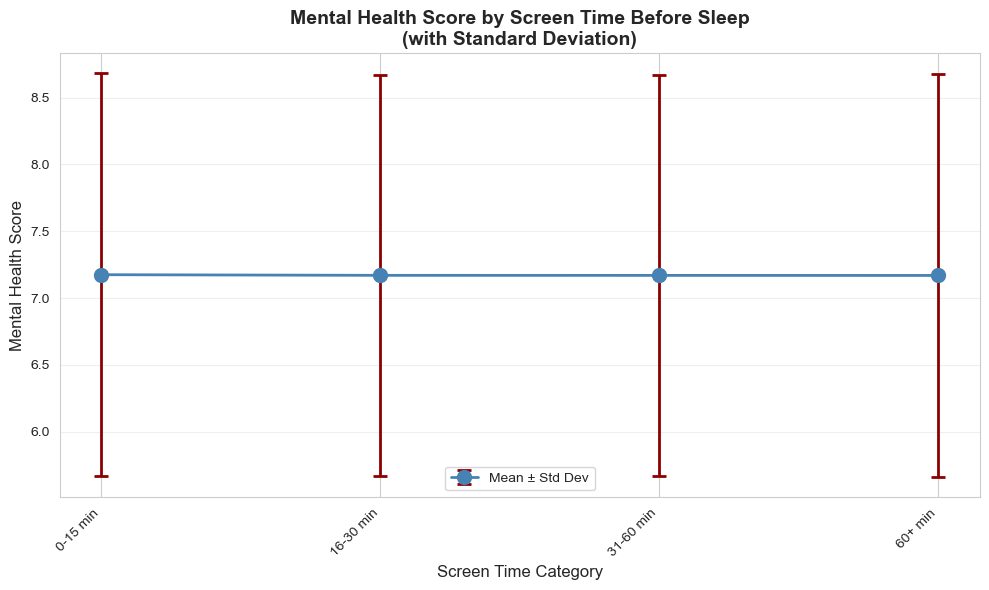

✓ Saved: RQ4_Figure2_BarChart.png


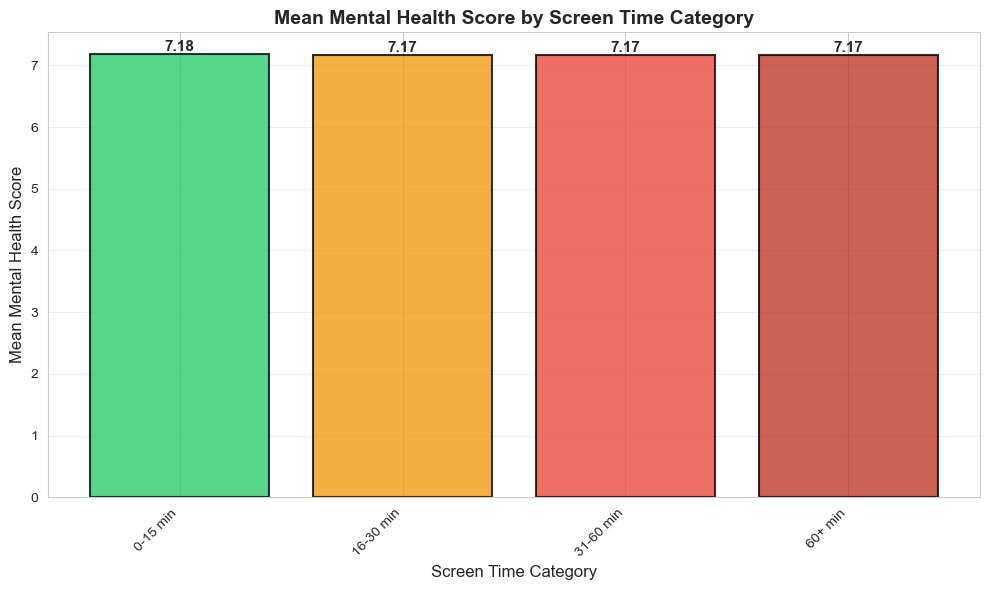

✓ Saved: RQ4_Figure3_BoxPlot.png


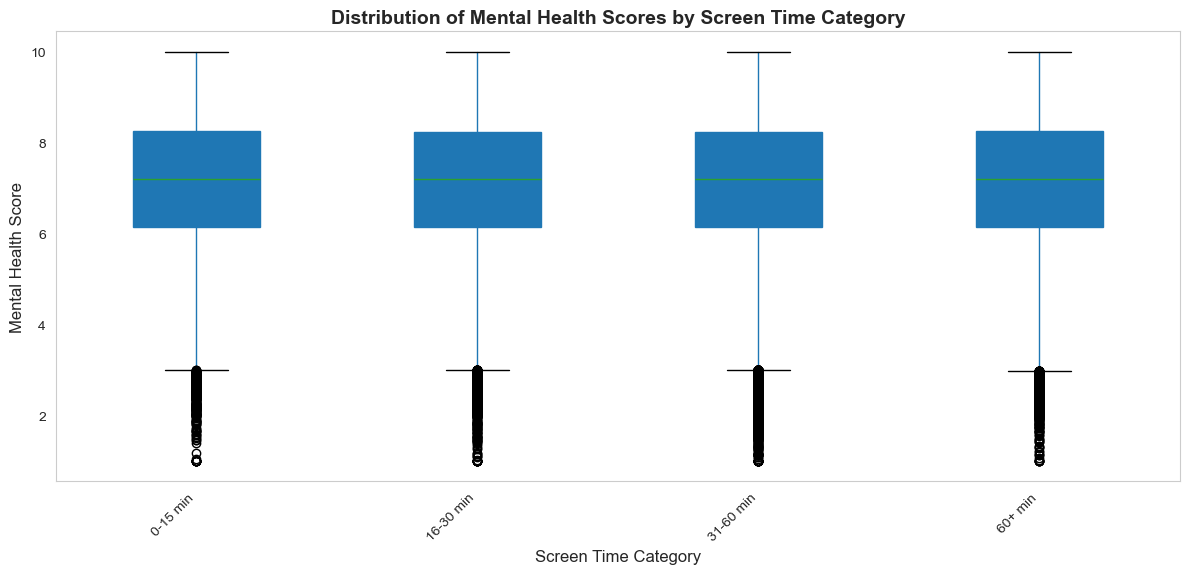

✓ Saved: RQ4_Figure4_ViolinPlot.png


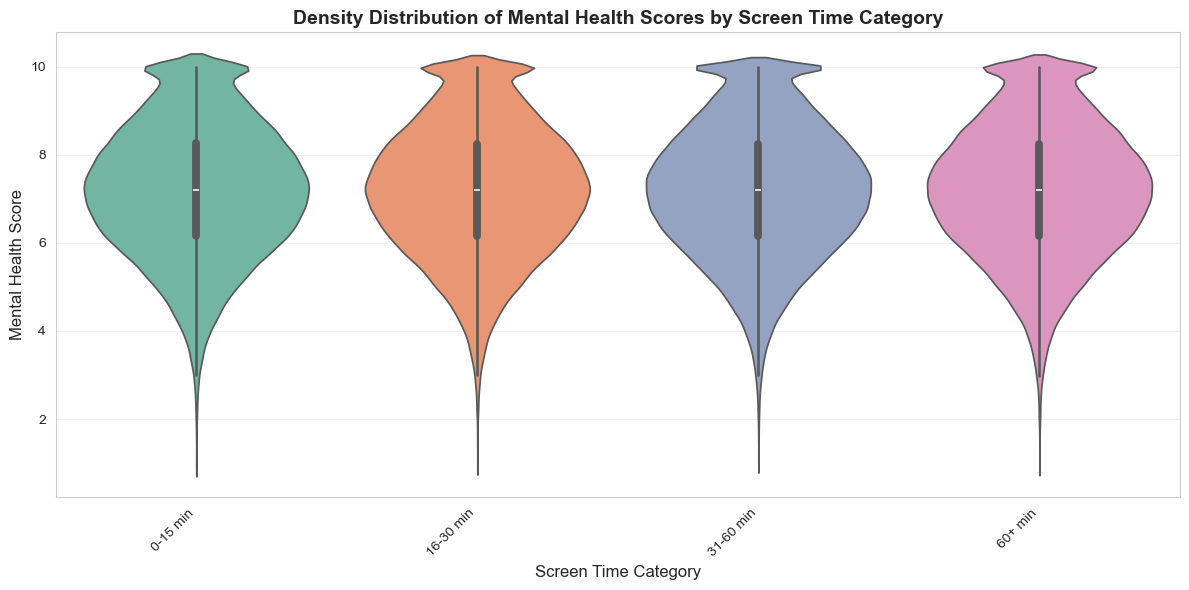

✓ Saved: RQ4_Figure5_Heatmap.png


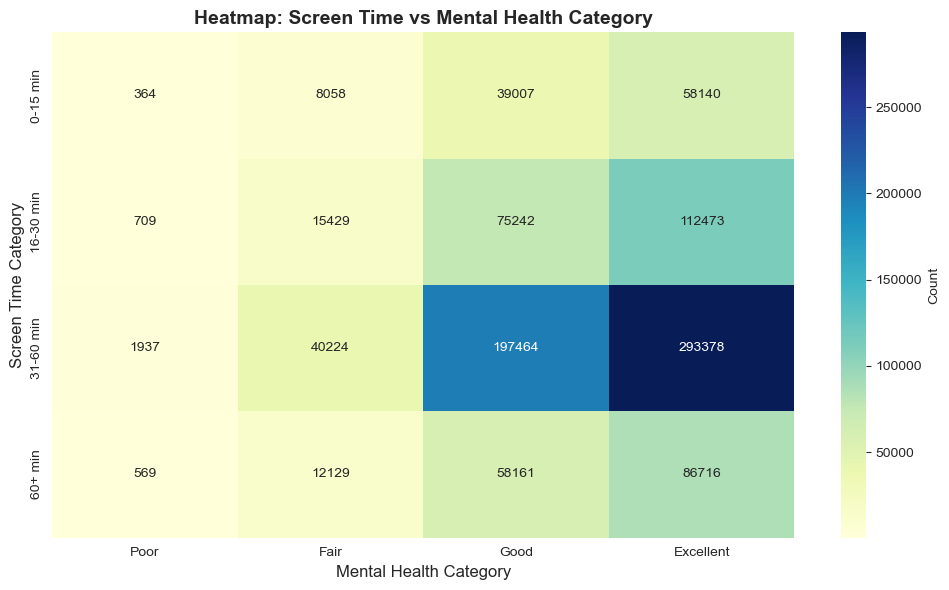

✓ Saved: RQ4_Figure6_StackedBar_Percentage.png


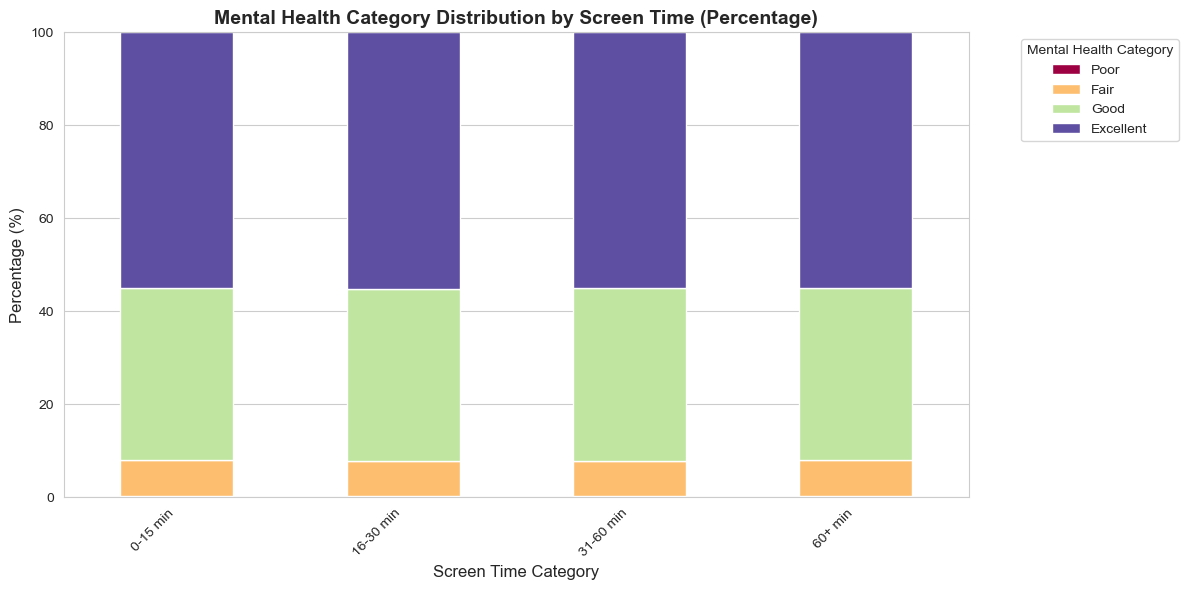

C:\Users\patil\AppData\Local\Temp\ipykernel_9496\2886094125.py:328: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\patil\AppData\Local\Temp\ipykernel_9496\2886094125.py:330: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(fig7_path, dpi=300, bbox_inches='tight')


✓ Saved: RQ4_Figure7_ScatterPlot_TrendLine.png


C:\Users\patil\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


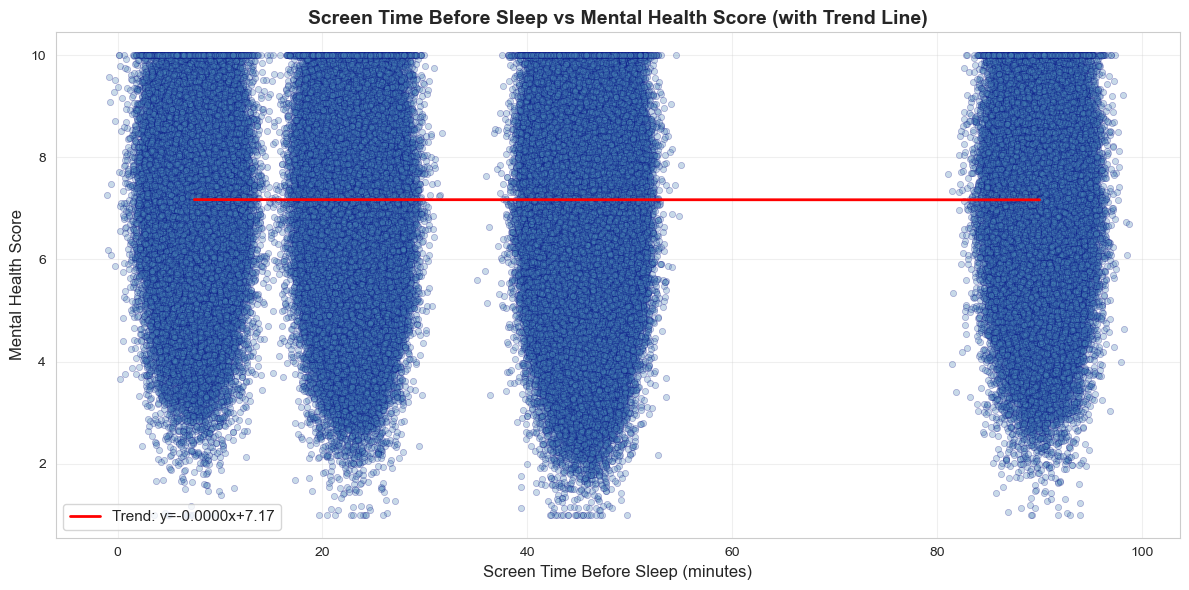


ANALYSIS COMPLETE!

Output files saved to: C:\Users\patil\output

Generated Files:
  • CSV Tables:
    - RQ4_Summary_Statistics.csv
    - RQ4_Table1_Mean_Scores.csv
    - RQ4_Table2_Crosstab_ScreenTime_MentalHealth.csv
  • Visualizations (7 Figures):
    - RQ4_Figure1_LineChart_ErrorBars.png
    - RQ4_Figure2_BarChart.png
    - RQ4_Figure3_BoxPlot.png
    - RQ4_Figure4_ViolinPlot.png
    - RQ4_Figure5_Heatmap.png
    - RQ4_Figure6_StackedBar_Percentage.png
    - RQ4_Figure7_ScatterPlot_TrendLine.png
    - RQ4_Figure6_StackedBar_Percentage.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path
from scipy import stats

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Set paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_ROOT / "data" / "genz_social_media_usage_1M.csv"
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

print("=" * 80)
print("RQ4: Screen Time Before Sleep vs Mental Health Analysis")
print("=" * 80)

# Load data
try:
    df = pd.read_csv('genz_social_media_usage_1Million.csv')
    print(f"\n✓ Data loaded successfully: {len(df)} records")
except FileNotFoundError:
    print(f"ERROR: Data file not found at {DATA_PATH}")
    raise

# Check for required columns
required_cols = ["screen_time_before_sleep", "mental_health_score"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"ERROR: Missing columns: {missing_cols}")
    print(f"Available columns: {df.columns.tolist()}")
    raise ValueError(f"Missing required columns: {missing_cols}")

print(f"✓ Required columns found: {required_cols}")

# ============================================================================
# DATA PREPARATION: Create Screen Time Bins
# ============================================================================
print("\n" + "=" * 80)
print("1. DATA PREPARATION: Screen Time Binning")
print("=" * 80)

bins = [0, 15, 30, 60, 300]
labels = ["0-15 min", "16-30 min", "31-60 min", "60+ min"]

df["screen_bin"] = pd.cut(
    df["screen_time_before_sleep"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Check for missing values
missing_count = df["screen_bin"].isna().sum()
if missing_count > 0:
    print(f"⚠ Warning: {missing_count} records with missing screen_bin values")
    df = df.dropna(subset=["screen_bin"])

print(f"✓ Screen time bins created successfully")
print(f"  Categories: {labels}")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "=" * 80)
print("2. SUMMARY STATISTICS BY SCREEN TIME CATEGORY")
print("=" * 80)

# Mean scores
mean_scores = df.groupby("screen_bin", observed=True)["mental_health_score"].mean()
print("\nMean Mental Health Scores:")
print(mean_scores.round(2))

# Detailed statistics
summary_stats = df.groupby("screen_bin", observed=True)["mental_health_score"].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Median', 'median'),
    ('Q3', lambda x: x.quantile(0.75)),
    ('Max', 'max')
]).round(2)

print("\nDetailed Statistics:")
print(summary_stats)

# Save detailed statistics
stats_path = OUTPUT_DIR / "RQ4_Summary_Statistics.csv"
summary_stats.to_csv(stats_path)
print(f"\n✓ Summary statistics saved to: {stats_path}")

# ============================================================================
# TABLE 1: Mean Scores by Category
# ============================================================================
print("\n" + "=" * 80)
print("3. TABLE 1: Mean Mental Health Scores")
print("=" * 80)

table1 = pd.DataFrame({
    'Screen_Time_Category': mean_scores.index,
    'Mean_Mental_Health_Score': mean_scores.values.round(2),
    'Number_of_Users': df.groupby("screen_bin", observed=True).size().values
})

print("\nTable 1:")
print(table1)

table1_path = OUTPUT_DIR / "RQ4_Table1_Mean_Scores.csv"
table1.to_csv(table1_path, index=False)
print(f"\n✓ Table 1 saved to: {table1_path}")

# ============================================================================
# TABLE 2: Crosstab Analysis (Mental Health Categories)
# ============================================================================
print("\n" + "=" * 80)
print("4. TABLE 2: Crosstab - Screen Time vs Mental Health Categories")
print("=" * 80)

# Define mental health categories
df["mental_health_category"] = pd.cut(
    df["mental_health_score"],
    bins=[0, 3, 5, 7, 10],
    labels=["Poor", "Fair", "Good", "Excellent"]
)

crosstab_table = pd.crosstab(
    df["screen_bin"],
    df["mental_health_category"],
    margins=True
)

print("\nTable 2:")
print(crosstab_table)

table2_path = OUTPUT_DIR / "RQ4_Table2_Crosstab_ScreenTime_MentalHealth.csv"
crosstab_table.to_csv(table2_path)
print(f"\n✓ Table 2 saved to: {table2_path}")

# ============================================================================
# STATISTICAL ANALYSIS: ANOVA
# ============================================================================
print("\n" + "=" * 80)
print("5. STATISTICAL ANALYSIS: ANOVA Test")
print("=" * 80)
groups = [group["mental_health_score"].values for name, group in df.groupby("screen_bin", observed=True)]
f_stat, p_value = stats.f_oneway(*groups)

print(f"\nANOVA Results:")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"  ✓ Significant difference found (p < 0.05)")
else:
    print(f"  ✗ No significant difference (p >= 0.05)")

# ============================================================================
# VISUALIZATIONS
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 80)
print("6. GENERATING VISUALIZATIONS")
print("=" * 80)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Grouping data
group_data = df.groupby("screen_bin")["mental_health_score"]
means = group_data.mean()
stds = group_data.std()

# X positions
x_pos = np.arange(len(means))

# Plot with error bars
ax1.errorbar(
    x_pos, means, yerr=stds,
    fmt='o-', linewidth=2, markersize=10,
    capsize=5, capthick=2,
    color='steelblue', ecolor='darkred',
    label='Mean ± Std Dev'
)

# Labels & formatting
ax1.set_xticks(x_pos)
ax1.set_xticklabels(means.index, rotation=45, ha='right')
ax1.set_title('Mental Health Score by Screen Time Before Sleep\n(with Standard Deviation)', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Screen Time Category', fontsize=12)
ax1.set_ylabel('Mental Health Score', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

# Save figure
plt.tight_layout()
fig1_path = OUTPUT_DIR / "RQ4_Figure1_LineChart_ErrorBars.png"
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')

print(f"✓ Saved: {fig1_path.name}")

plt.show()

# Figure 2: Bar Chart with Value Labels
fig2, ax2 = plt.subplots(figsize=(10, 6))
bars = ax2.bar(x_pos, means, color=['#2ecc71', '#f39c12', '#e74c3c', '#c0392b'], 
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(means.index, rotation=45, ha='right')
ax2.set_title('Mean Mental Health Score by Screen Time Category', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Screen Time Category', fontsize=12)
ax2.set_ylabel('Mean Mental Health Score', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
fig2_path = OUTPUT_DIR / "RQ4_Figure2_BarChart.png"
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig2_path.name}")
plt.show()

# Figure 3: Box Plot
fig3, ax3 = plt.subplots(figsize=(12, 6))
df.boxplot(column="mental_health_score", by="screen_bin", ax=ax3, 
           patch_artist=True, grid=False)
ax3.set_title('Distribution of Mental Health Scores by Screen Time Category', 
              fontsize=14, fontweight='bold')
ax3.set_xlabel('Screen Time Category', fontsize=12)
ax3.set_ylabel('Mental Health Score', fontsize=12)
plt.suptitle('')  # Remove automatic title
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig3_path = OUTPUT_DIR / "RQ4_Figure3_BoxPlot.png"
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig3_path.name}")
plt.show()

# Figure 4: Violin Plot
fig4, ax4 = plt.subplots(figsize=(12, 6))
screen_order = ["0-15 min", "16-30 min", "31-60 min", "60+ min"]
sns.violinplot(data=df, x="screen_bin", y="mental_health_score", 
               order=screen_order, ax=ax4, palette="Set2", hue="screen_bin", legend=False)
ax4.set_title('Density Distribution of Mental Health Scores by Screen Time Category', 
              fontsize=14, fontweight='bold')
ax4.set_xlabel('Screen Time Category', fontsize=12)
ax4.set_ylabel('Mental Health Score', fontsize=12)
ax4.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig4_path = OUTPUT_DIR / "RQ4_Figure4_ViolinPlot.png"
plt.savefig(fig4_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig4_path.name}")
plt.show()

# Figure 5: Heatmap of Crosstab
fig5, ax5 = plt.subplots(figsize=(10, 6))
crosstab_plot = crosstab_table.iloc[:-1, :-1]  # Remove margins
sns.heatmap(crosstab_plot, annot=True, fmt='d', cmap='YlGnBu', ax=ax5, cbar_kws={'label': 'Count'})
ax5.set_title('Heatmap: Screen Time vs Mental Health Category', fontsize=14, fontweight='bold')
ax5.set_xlabel('Mental Health Category', fontsize=12)
ax5.set_ylabel('Screen Time Category', fontsize=12)
plt.tight_layout()
fig5_path = OUTPUT_DIR / "RQ4_Figure5_Heatmap.png"
plt.savefig(fig5_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig5_path.name}")
plt.show()

# Figure 6: Stacked Bar Chart (Percentages)
fig6, ax6 = plt.subplots(figsize=(12, 6))
crosstab_normalized = crosstab_table.iloc[:-1, :-1].div(crosstab_table.iloc[:-1, -1], axis=0) * 100
crosstab_normalized.plot(kind='bar', stacked=True, ax=ax6, colormap='Spectral')
ax6.set_title('Mental Health Category Distribution by Screen Time (Percentage)', 
              fontsize=14, fontweight='bold')
ax6.set_xlabel('Screen Time Category', fontsize=12)
ax6.set_ylabel('Percentage (%)', fontsize=12)
ax6.legend(title='Mental Health Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax6.set_ylim([0, 100])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig6_path = OUTPUT_DIR / "RQ4_Figure6_StackedBar_Percentage.png"
plt.savefig(fig6_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig6_path.name}")
plt.show()

# Figure 7: Scatter Plot with Trend Line
fig7, ax7 = plt.subplots(figsize=(12, 6))
# Map screen time bins to numeric values
bin_mapping = {"0-15 min": 7.5, "16-30 min": 23, "31-60 min": 45.5, "60+ min": 90}
df["screen_time_numeric"] = df["screen_bin"].map(bin_mapping).astype(float)
# Remove any NaN values
df_clean = df[df["screen_time_numeric"].notna()].copy()

# Add jitter for better visualization
jitter = np.random.normal(0, 2, size=len(df_clean))
screen_vals = df_clean["screen_time_numeric"].values.astype(float)
mental_vals = df_clean["mental_health_score"].values.astype(float)
ax7.scatter(screen_vals + jitter, mental_vals, 
           alpha=0.3, s=20, color='steelblue', edgecolors='navy', linewidth=0.5)

# Add trend line
z = np.polyfit(screen_vals, mental_vals, 1)
p = np.poly1d(z)
x_trend = np.linspace(screen_vals.min(), screen_vals.max(), 100)
ax7.plot(x_trend, p(x_trend), "r-", linewidth=2, label=f'Trend: y={z[0]:.4f}x+{z[1]:.2f}')

ax7.set_title('Screen Time Before Sleep vs Mental Health Score (with Trend Line)', 
              fontsize=14, fontweight='bold')
ax7.set_xlabel('Screen Time Before Sleep (minutes)', fontsize=12)
ax7.set_ylabel('Mental Health Score', fontsize=12)
ax7.legend(fontsize=11)
ax7.grid(alpha=0.3)
plt.tight_layout()
fig7_path = OUTPUT_DIR / "RQ4_Figure7_ScatterPlot_TrendLine.png"
plt.savefig(fig7_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig7_path.name}")
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nOutput files saved to: {OUTPUT_DIR}")
print("\nGenerated Files:")
print(f"  • CSV Tables:")
print(f"    - RQ4_Summary_Statistics.csv")
print(f"    - RQ4_Table1_Mean_Scores.csv")
print(f"    - RQ4_Table2_Crosstab_ScreenTime_MentalHealth.csv")
print(f"  • Visualizations (7 Figures):")
print(f"    - RQ4_Figure1_LineChart_ErrorBars.png")
print(f"    - RQ4_Figure2_BarChart.png")
print(f"    - RQ4_Figure3_BoxPlot.png")
print(f"    - RQ4_Figure4_ViolinPlot.png")
print(f"    - RQ4_Figure5_Heatmap.png")
print(f"    - RQ4_Figure6_StackedBar_Percentage.png")
print(f"    - RQ4_Figure7_ScatterPlot_TrendLine.png")
print("=" * 80)
print(f"    - RQ4_Figure6_StackedBar_Percentage.png")